In [1]:
from dotenv import load_dotenv
load_dotenv(".env", override=True)
%load_ext autoreload
%autoreload 2

# Deepagent for Research

We will use the `deepagents` package to create a research agent. When using the `deepagents` package, it's important to: 

1. Understand the native tools available
2. Supply task-specific tools
3. Supply task-specific instructions
4. Supply task-specific sub-agents

## Task-Specific Tools 

You can see an overview of the native tools in the [deepagents package README](https://github.com/langchain-ai/deepagents?tab=readme-ov-file#model) as well as the [quickstarts README](https://github.com/langchain-ai/deepagents-quickstarts). We'll extend this with two task-specific tools. 

### Search Tool 

There are different search tools that we can use. For example, we can use [Tavily](https://www.tavily.com/) to search for relevant URLs, then fetches the full webpage content.

### Think Tool 

We'll supply a [think tool](https://www.anthropic.com/engineering/claude-think-tool), which is a useful way to help audit agent decision making. 

In [2]:
from research_agent.tools import tavily_search, think_tool
tools = [tavily_search, think_tool]

## Task-Specific Instructions
 
Next, let's define task specific instructions using [a few prompting techniques for agents](https://youtu.be/XSZP9GhhuAc?si=zowpViL-2j-vI9hA):

### 1. Think Like The Agent
What instructions would you give a new work colleague?
- **Read the question carefully** - What specific information does the user need?
- **Start with broader searches** - Use broad, comprehensive queries first
- **After each search, pause and assess** - Do I have enough to answer? What's still missing?
- **Execute narrower searches as you gather information** - Fill in the gaps.

### 2. Concrete Heuristics (Prevent "Spin-Out" on excessive tool calls)
Use **Hard Limits** to prevent the research agent from calling tools excessively:
- **Stop when you can answer confidently** - Don't keep searching for perfection.
- **Give it budgets** - Use 2-3 search tool calls for simple queries. Use up to 5 for complex queries.
- **Limit** - Always stop after 5 search tool calls if you cannot find the right source(s).

### 3. Show your thinking
After each search tool calling, use [`think_tool` to analyze the results](https://www.anthropic.com/engineering/claude-think-tool):
- What key information did I find? 
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?

In [3]:
from datetime import datetime
from utils import show_prompt, format_messages
from research_agent.prompts import (
    RESEARCHER_INSTRUCTIONS,
    RESEARCH_WORKFLOW_INSTRUCTIONS,
    SUBAGENT_DELEGATION_INSTRUCTIONS,
)

In [4]:
show_prompt(RESEARCHER_INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the research tools provided to you to find resources that can help answer the research      │
│  question.                                                                                                      │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Research Tools>                                                                                     │
│  You have access to two specific research tools:                                                                │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Research Tools>                                                                                    │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher with limited time. Follow these steps:                                           │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 5 search tool calls maximum                                                   │
│  - **Always stop**: After 5 search tool calls if you cannot find the right sources                              │
│                                                       

## Task-Specific Sub-Agents

You can specify [custom subagents](https://github.com/langchain-ai/deepagents?tab=readme-ov-file#subagents) as a means of context isolation. 

Here's well define a sub-agent that can search the web for information. 

In [5]:
# Get current date
current_date = datetime.now().strftime("%Y-%m-%d")

# Create research sub-agent
research_sub_agent = {
    "name": "research-agent",
    "description": "Delegate research to the sub-agent researcher. Only give this researcher one topic at a time.",
    "system_prompt": RESEARCHER_INSTRUCTIONS.format(date=current_date),
    "tools": [tavily_search, think_tool],
}

## Putting it all together

### Instructions

Now, we can look at all of our instructions together. 

In [6]:
# Limits
max_concurrent_research_units = 3
max_researcher_iterations = 3

# Combine orchestrator instructions (RESEARCHER_INSTRUCTIONS only for sub-agents)
INSTRUCTIONS = (
    RESEARCH_WORKFLOW_INSTRUCTIONS
    + "\n\n"
    + "=" * 80
    + "\n\n"
    +  SUBAGENT_DELEGATION_INSTRUCTIONS.format(
        max_concurrent_research_units=max_concurrent_research_units,
        max_researcher_iterations=max_researcher_iterations,
    )
)

show_prompt(INSTRUCTIONS)

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Research Workflow                                                                                            │
│                                                                                                                 │
│  Follow this workflow for all research requests:                                                                │
│                                                                                                                 │
│  1. **Plan**: Create a todo list with write_todos to break down the research into focused tasks                 │
│  2. **Save the request**: Use write_file() to save the user's research question to `/research_request.md`       │
│  3. **Research**: Delegate research tasks to sub-agents using the task() tool - ALWAYS use sub-agents for       │
│  research, never conduct research yourself                                                                      │
│  4. **Synthesize**: Review all sub-agent findings and consolidate citations (each unique URL gets one number    │
│  across all findings)                                                                                           │
│  5. **Write Report**: Write a comprehensive final report to `/final_report.md` (see Report Writing Guidelines   │
│  below)                                                                                                         │
│  6. **Verify**: Read `/research_request.md` and confirm you've addressed all aspects with proper citations and  │
│  structure                                                                                                      │
│                                                                                                                 │
│  ## Research Planning Guidelines                                                                                │
│  - Batch similar research tasks into a single TODO to minimize overhead                                         │
│  - For simple fact-finding questions, use 1 sub-agent                                                           │
│  - For comparisons or multi-faceted topics, delegate to multiple parallel sub-agents                            │
│  - Each sub-agent should research one specific aspect and return findings                                       │
│                                                                                                                 │
│  ## Report Writing Guidelines                                                                                   │
│                                                                                                                 │
│  When writing the final report to `/final_report.md`, follow these structure patterns:                          │
│                                                                                                                 │
│  **For comparisons:**                                                                                           │
│  1. Introduction                                                                                                │
│  2. Overview of topic A                                                                                         │
│  3. Overview of topic B                                                                                         │
│  4. Detailed comparison                                                                                         │
│  5. Conclusion                                                                                                  │
│                                                                                                                 │
│  **For lists/rankings:**                              

### Create the agent

Now, we create our deepagent with these components. 

In [7]:
from IPython.display import Image, display
from deepagents import create_deep_agent
from langchain_openai import ChatOpenAI
import os

# Kimi Code (Moonshot) via OpenAI-compatible endpoint.
# Note: Kimi Code models require temperature=1.
model = ChatOpenAI(
    model=os.getenv("KIMI_MODEL", "kimi-code"),
    temperature=1.0,
    api_key=os.getenv("KIMI_API_KEY"),
    base_url=os.getenv("KIMI_BASE_URL", "https://api.kimi.com/coding/v1"),
)


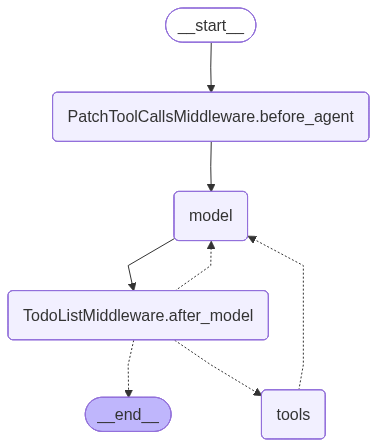

In [8]:
# Create the agent
agent = create_deep_agent(
      model=model,
      tools=tools, 
      system_prompt=INSTRUCTIONS,
      subagents=[research_sub_agent],
  )
  
# Show the agent
display(Image(agent.get_graph().draw_mermaid_png()))

In [9]:
result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "research context engineering approaches used to build AI agents",
            }
        ],
    }, 
)
format_messages(result["messages"])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ research context engineering approaches used to build AI agents                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save the research request to /research_request.md",                                           │
│       "status": "in_progress"                                                                                   │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research on context engineering approaches for AI agents to a sub-agent",            │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings from the sub-agent",                                                      │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write comprehensive final report to /final_report.md",                                        │
│       "status": "pending"                                                                                       │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Verify the report addresses the research request",                                            │
│       "status": "pending"                                                                                       │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: tool_xlFX5umJFiBbmfQdAtbRGs8m                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save the research request to /research_request.md', 'status':                │
│ 'in_progress'}, {'content': 'Delegate research on context engineering approaches for AI agents to a sub-agent', │
│ 'status': 'pending'}, {'content': 'Synthesize findings from the sub-agent', 'status': 'pending'}, {'content':   │
│ 'Write comprehensive final report to /final_report.md', 'status': 'pending'}, {'content': 'Verify the report    │
│ addresses the research request', 'status': 'pending'}]                                                          │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_file                                                                                        │
│    Args: {                                                                                                      │
│   "content": "# Research Request\n\n**Research Question:** Research context engineering approaches used to      │
│ build AI agents.\n\n**Goal:** Provide a comprehensive overview of context engineering techniques, strategies,   │
│ and approaches used to construct AI agents, including but not limited to prompt engineering, context window     │
│ management, retrieval-augmented generation, memory architectures, and tooling/patterns for maintaining and      │
│ structuring context within agentic systems.\n",                                                                 │
│   "file_path": "/research_request.md"                                                                           │
│ }                                                                                                               │
│    ID: tool_z6Yjj9OVmFnrCth8bDC67itZ                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated file /research_request.md                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: read_file                                                                                         │
│    Args: {                                                                                                      │
│   "file_path": "/final_report.md",                                                                              │
│   "offset": 100,                                                                                                │
│   "limit": 50                                                                                                   │
│ }                                                                                                               │
│    ID: tool_PlbzKZ711r5pronwO47LQGmb                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│    101  [14] M. Tanner, “Context Engineering: A Practical Guide for AI Agents (2026),” Sourcegraph.             │
│ https://sourcegraph.com/blog/context-engineering                                                                │
│    102                                                                                                          │
│    103  [15] OpenAI, “Context Management,” OpenAI Agents SDK Documentation.                                     │
│ https://openai.github.io/openai-agents-js/guides/context/                                                       │
│    104                                                                                                          │
│    105  [16] CodeSignal Learn, “Getting Started with OpenAI Agents SDK.”                                        │
│ https://codesignal.com/learn/courses/introduction-to-openai-agents-sdk-in-python/lessons/creating-and-running-y │
│ our-first-openai-agent-in-python-1                                                                              │
│    106                                                                                                          │
│    107  [Bhagwat Chate] Bhagwat Chate, “Building Multi-Tier Memory for Agentic AI Systems,” LinkedIn.           │
│ https://www.linkedin.com/posts/bhagwat-chate-ai_genai-langgraph-systemdesign-activity-7381535222237933568-sU7m  │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: write_todos                                                                                       │
│    Args: {                                                                                                      │
│   "todos": [                                                                                                    │
│     {                                                                                                           │
│       "content": "Save the research request to /research_request.md",                                           │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Delegate research on context engineering approaches for AI agents to a sub-agent",            │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Synthesize findings from the sub-agent",                                                      │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Write comprehensive final report to /final_report.md",                                        │
│       "status": "completed"                                                                                     │
│     },                                                                                                          │
│     {                                                                                                           │
│       "content": "Verify the report addresses the research request",                                            │
│       "status": "completed"                                                                                     │
│     }                                                                                                           │
│   ]                                                                                                             │
│ }                                                                                                               │
│    ID: tool_jyzrQZiWhc6KIOu2hiCGuMEP                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Updated todo list to [{'content': 'Save the research request to /research_request.md', 'status': 'completed'},  │
│ {'content': 'Delegate research on context engineering approaches for AI agents to a sub-agent', 'status':       │
│ 'completed'}, {'content': 'Synthesize findings from the sub-agent', 'status': 'completed'}, {'content': 'Write  │
│ comprehensive final report to /final_report.md', 'status': 'completed'}, {'content': 'Verify the report         │
│ addresses the research request', 'status': 'completed'}]                                                        │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Research complete. A comprehensive final report has been written to `/final_report.md` covering the main        │
│ context engineering approaches for AI agents.                                                                   │
│                                                                                                                 │
│ ## Summary                                                                                                      │
│                                                                                                                 │
│ The report organizes the topic into nine sections:                                                              │
│                                                                                                                 │
│ 1. **Introduction** — Defines context engineering as the discipline of curating the full set of tokens an LLM   │
│ sees during inference, extending beyond single prompts.                                                         │
│ 2. **Core Principles** — Covers treating context as a scarce resource, offloading, isolation,                   │
│ compaction/summarization, and just-in-time retrieval.                                                           │
│ 3. **Prompt and System-Message Design** — Discusses production prompt structure, system-message best practices, │
│ and output-format discipline.                                                                                   │
│ 4. **Context Window Management** — Explains trimming, summarization, compaction, structured note-taking, and    │
│ multi-agent decomposition; also references the "lost in the middle" research.                                   │
│ 5. **Retrieval-Augmented Generation and Vector Memory** — Describes RAG pipelines, semantic memory, hybrid      │
│ retrieval, and session memory.                                                                                  │
│ 6. **Memory Architectures** — Distinguishes short-term and long-term memory, and presents LangGraph's           │
│ mutability/lifetime framing (static runtime, dynamic state, persistent store).                                  │
│ 7. **Agent Patterns and Context** — ReAct, reflection, tool use, and multi-agent orchestration.                 │
│ 8. **Tooling and Libraries** — LangChain/LangGraph, OpenAI Agents SDK, Mem0, vector DBs, Redis, PostgreSQL,     │
│ Neo4j, and embedding providers.                                                                                 │
│ 9. **Conclusion** — Synthesizes the key takeaways.                                                              │
│                                                                                                                 │
│ The report cites 15 sources, including authoritative documentation from Anthropic, LangChain, and the OpenAI    │
│ Agents SDK, plus the "Lost in the Middle" research paper and supporting industry articles.                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [10]:
from deepagents.backends.utils import file_data_to_string

# Convert a specific file to string
file_content = file_data_to_string(result["files"]['/final_report.md'])
show_prompt(file_content) 

╭──────────────────────────────────────────────────── Prompt ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│  # Context Engineering Approaches for AI Agents                                                                 │
│                                                                                                                 │
│  ## 1. Introduction                                                                                             │
│                                                                                                                 │
│  Context engineering is the discipline of curating, structuring, and maintaining the information an AI agent    │
│  can access at any given step. It extends beyond the wording of a single prompt to encompass the entire set of  │
│  tokens an LLM sees during inference: system instructions, tool definitions, conversation history, retrieved    │
│  documents, memory, and user inputs [9][10]. Because context windows are finite and attention is not uniform    │
│  across all tokens, the way an agent's context is assembled directly affects its reasoning quality, cost,       │
│  latency, and reliability [9][12]. This report surveys the main approaches and best practices used to build AI  │
│  agents with robust context engineering.                                                                        │
│                                                                                                                 │
│  ## 2. Core Principles                                                                                          │
│                                                                                                                 │
│  The central goal of context engineering is to provide the smallest possible set of high-signal tokens needed   │
│  for the model to act correctly [9]. Several principles guide this work:                                        │
│                                                                                                                 │
│  - **Context as a scarce resource.** More tokens do not necessarily mean better performance. Irrelevant or      │
│  redundant information can dilute attention and lead to "context rot," where a model's accuracy declines as     │
│  the prompt grows [6][9].                                                                                       │
│  - **Offloading.** Push data that does not need to be in the prompt into external storage — files, databases,   │
│  vector stores, or APIs — and retrieve only what is needed [1][9].                                              │
│  - **Isolation.** Different agents or modules should receive only the context they need. This reduces           │
│  cross-contamination, lowers noise, and makes systems easier to reason about [1].                               │
│  - **Compaction and summarization.** Long conversations and large states should be periodically summarized,     │
│  pruned, or restructured so the context window remains focused on current needs [1][9][11].                     │
│  - **Just-in-time retrieval.** Instead of pre-loading every potentially relevant document, agents should fetch  │
│  context dynamically through tools, identifiers, or search queries at the moment it is needed [9][14].          │
│                                                                                                                 │
│  ## 3. Prompt and System-Message Design                                                                         │
│                                                                                                                 │
│  A production prompt is usually composed of three logical blocks: a system prompt that defines role and         │
│  behavior, additional context such as retrieved docume

Trace: 

https://smith.langchain.com/public/72d23852-4616-4bcc-8d8a-b0d1905c945b/r